In [1]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

import pytorch_lightning as pl

from torchmetrics.classification import BinaryAUROC

from datetime import datetime
from xaikd import bases as xaikd_bases
from tqdm.notebook import tqdm

import numpy.typing as npt

In [2]:
WITH_LAST_LAYER_BIAS = False
DEVICE = "cpu"

In [3]:
# Build Dataset
def build_task_targets():
    bin_rep1 = np.arange(8) % 2
    bin_rep2 = (np.arange(8) //2) % 2
    bin_rep3 = (np.arange(8) // 4) % 2
    
    y_t1 = np.logical_xor(bin_rep1, bin_rep2).astype(int)
    y_t2 = np.logical_xor(bin_rep1, bin_rep3).astype(int)
    y_t3 = np.logical_xor(bin_rep2, bin_rep3).astype(int)
    
    y = np.stack([y_t1, y_t2, y_t3]).T
    
    df = pd.DataFrame(
        dict(
            x1 = bin_rep1,
            x2 = bin_rep2,
            x3 = bin_rep3,
            x1_xor_x2 = y_t1,
            x1_xor_x3 = y_t2,
            x2_xor_x3 = y_t3
        )
    )
    return df, y

df, arr_task_targets = build_task_targets()
df

,x1,x2,x3,x1_xor_x2,x1_xor_x3,x2_xor_x3
0,0,0,0,0,0,0
1,1,0,0,1,1,0
2,0,1,0,1,0,1
3,1,1,0,0,1,1
4,0,0,1,0,1,1
5,1,0,1,1,0,1
6,0,1,1,1,1,0
7,1,1,1,0,0,0


In [4]:
def generate_dataset(num_per_groups=200, seed=1):
    rng = np.random.default_rng(seed=1)
    
    df, arr_task_targets = build_task_targets()
    
    arr_xs = []
    arr_ys = []
    
    arr_centers = 2*df[["x1", "x2", "x3"]].values - 1
    
    assert arr_centers.shape[0] == 8
    
    for cix in range(8):
        center = arr_centers[cix]
        group_x =  rng.normal(scale=0.5, size=(num_per_groups, 3)) + center
        arr_xs.append(group_x)
        
        
        code = np.array(list(np.binary_repr(2, width=3))).astype(int)
    
        ys = np.tile(arr_task_targets[cix], num_per_groups).reshape((num_per_groups, 3))
        arr_ys.append(ys)
        
    X = np.vstack(arr_xs)
    y = np.vstack(arr_ys)
    
    assert X.shape[0] == y.shape[0] == num_per_groups * 8 
    
    num_datapoints = num_per_groups * 8 
    
    return train_test_split(X, y, test_size=0.5, random_state=seed)

X_train, X_test, y_train, y_test = generate_dataset() 

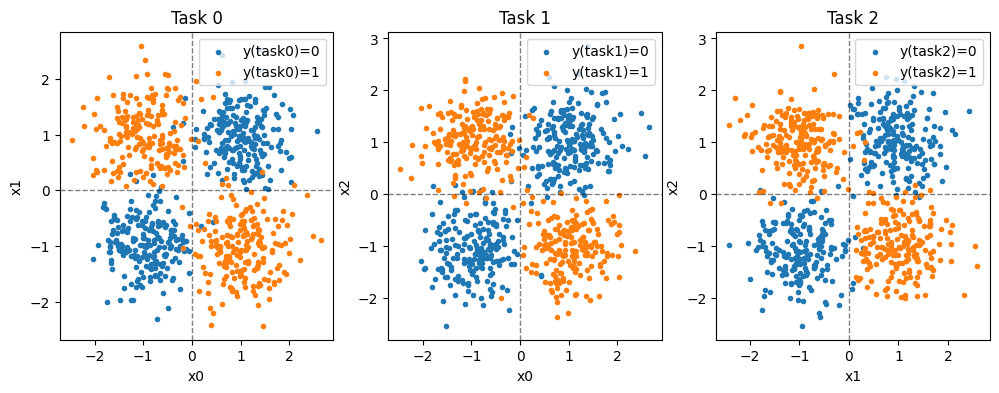

In [5]:
def viz(X, y):
    
    plt.figure(figsize=(3*4, 4))
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    for tidx in range(3):
        plt.subplot(1, 3, tidx + 1)
        plt.title(f"Task {tidx}")
        
        coord1, coord2 = arr_coords[tidx]
        for ans in [0, 1]:

            selected = y[:, tidx] == ans

            plt.scatter(
                X[selected, coord1], X[selected, coord2],
                marker=".",
                label=f"y(task{tidx})={ans}"
            )
        plt.axhline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.axvline(0, ls="--", lw=1, color="k", alpha=0.5)
        plt.legend()
        plt.xlabel(f"x{coord1}")
        plt.ylabel(f"x{coord2}")
        
viz(X_train, y_train)

# Construct Model and Train

In [6]:
class MLP(nn.Module):
    def __init__(self, num_tasks=3):
        super().__init__()
        
        d = 128
        
        self.lin1 = nn.Linear(3, d)
        self.act1 = nn.ReLU()
        self.lin2 = nn.Linear(d, num_tasks, bias=WITH_LAST_LAYER_BIAS)
    def forward(self, x):
        x = self.act1(self.lin1(x))
        x = self.lin2(x)
        
        out = [
            x[:, 0],
            x[:, 1],
            x[:, 2],
        ]
        
        return out
    def __str__(self):
        d, _ = self.lin1.weight.shape
        return f"MLP(d={d}, last_layer_bias={WITH_LAST_LAYER_BIAS})"
def ano():
    
    out = MLP()(torch.randn(10, 3))
    
    print(f"santity check: {MLP()} callable")
ano()

santity check: MLP(d=128, last_layer_bias=False) callable


In [7]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.SGD(
            self.parameters(), lr=self.lr, momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(3):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += (1/3)*F.binary_cross_entropy_with_logits(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()


In [8]:
pl.seed_everything(1)

dl_train = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=True,
)

dl_train_noshuffle = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train).float(),
        torch.from_numpy(y_train).float()
    ),
    batch_size=64,
    shuffle=False,
)

dl_test = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test).float(),
        torch.from_numpy(y_test).float()
    ),
    batch_size=64,
    shuffle=True,
)

model  = MLP()

trainer = pl.Trainer(
    max_epochs=500,
    default_root_dir="/tmp",
)

trainer.fit(ModelWrapper(model), dl_train, dl_test)

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Missing logger folder: /tmp/lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type | Params
---------------------------------
0 | encoder

Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


In [9]:
def estimate_task_auroc(model, dl, task_id):
    metric_auroc = BinaryAUROC()

    for x, y in dl:
        task_logit = model(x)[task_id]
        task_target = y[:, task_id]
        metric_auroc.update(task_logit, task_target)

    auroc = float(metric_auroc.compute())
    auroc = 1-auroc if auroc < 0.5 else auroc
    return auroc

def compute_aurocs():
    
    stats = dict()
    
    for tidx in range(3):
        
        for label, dl in [
            ("train", dl_train),
            ("test", dl_test)
        ]:            
            stats[f"auroc_task_{tidx}_{label}"] = estimate_task_auroc(model, dl, tidx)
    
    return stats

ref_stats = compute_aurocs()
ref_stats

{'auroc_task_0_train': 0.9920439720153809,
 'auroc_task_0_test': 0.9897671937942505,
 'auroc_task_1_train': 0.9867480397224426,
 'auroc_task_1_test': 0.9769731163978577,
 'auroc_task_2_train': 0.9896681904792786,
 'auroc_task_2_test': 0.9840741157531738}

# Extract Grad

In [20]:

def grad_hook(mod, inp, outp):
    outp.retain_grad()
    setattr(mod, "__outp", outp)


def compute_logodd_winning(logits):

    return torch.sign(logits) * logits
    
    
def extract_act_grad(model, dl, task_id):
    module_name = "act1"

    arr_logodd = []
    arr_act = []
    arr_ctx = []
    module = getattr(model, module_name)
    for x, y in dl:
                
        try:

            x.requires_grad_()
            hook = module.register_forward_hook(grad_hook)

            arr_logits = model(x)
        
            task_logit = arr_logits[task_id]

            logodd = compute_logodd_winning(task_logit)
            
            (logodd).sum().backward()
            
            act = getattr(module, "__outp")

            arr_logodd.append(logodd.detach().numpy())
            
            ctx = act.grad.detach().numpy()
            act = act.detach().numpy()
            arr_act.append(act)
            arr_ctx.append(ctx)
            
            
        finally:
            hook.remove()

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
    arr_logodd = np.hstack(arr_logodd)

    assert arr_logodd.shape == (arr_act.shape[0],)
    return arr_logodd, arr_act, arr_ctx

extract_act_grad(model, dl_train_noshuffle, 0);

In [11]:
def sanity_check():
    _, arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1, 2]:
        _, arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")
sanity_check()

arr_act(T0) == arr_act(T1)
arr_act(T0) == arr_act(T2)
all passed!


# Constructing Basis

In [12]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvals, eigvecs

## Baselines: PCA, GradPCA

In [84]:
class BasisInterface:
    def get_projection(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_projection(self, k: int):
        Uk =  self.U[:, :k]
        return Uk @ Uk.T


class GradPCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.eigvals, self.U = _solve_eigvecs(cov)
        
    def get_projection(self, k: int):
        Uk =  self.U[:, :k]
        return Uk @ Uk.T

In [41]:
# from https://github.com/jerry-chee/ModelPreserveCompressionNN/blob/main/id_utils.py
import scipy

def getID(k, Z, W=None, mode='kT'):
    '''
    calculates ID 
    mode: kT, WT (what to return)
    requires (d, n) format
    currently in numpy because pytorch doesn't support QR pivots
    k: number of columns
    Z: layer after nonlinearity
    ''' 
    assert(k <= Z.shape[1])
    # column-pivot QR
    R, P = scipy.linalg.qr((Z), mode='r', pivoting=True)
    if W is not None: Wk = W[:, P[0:k]]
    T = np.concatenate((
        np.identity(k),
        np.linalg.pinv(R[0:k, 0:k]) @ R[0:k, k:None]
        ), axis=1)
    T = T[:, np.argsort(P)]
    if mode == 'kT':
        return P[0:k], T
    elif mode == 'WT' and W is not None:
        return Wk, T
    else:
        raise NotImplementedError



class ActID(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        
    def get_projection(self, k: int):


        _, d = self.arr_act.shape
        
        k_idx, T = getID(k, self.arr_act)
        
        # shape: (k, d)
        mat_selection = np.eye(d)[k_idx, :]

        return  (mat_selection.T @ T)
        

def sanity_check():
    arr_act = torch.randn((32, 128))
    
    basis = ActID(None, arr_act, None, None)

    mat_proj = basis.get_projection(k=7)

sanity_check()

## Gradient-based InterDecom

In [77]:
class RelID(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        self.arr_act = arr_act
        self.arr_ctx = arr_ctx
        
    def get_interpolative_decom(self, k: int, verbose=False):


        A = self.arr_act
        C = self.arr_ctx
        _, d = self.arr_act.shape


        all_dims = set(np.arange(d).tolist())
        
        selected = []
        for _k in tqdm(range(k), desc="solve RelID", disable=not verbose):

            arr_proj_candidates = []
            # arr_proj_candidates = []
            arr_criteria = []
            arr_candidate_dims = list(all_dims.difference(selected))
            for _, i in enumerate(arr_candidate_dims):
                _selected = [*selected, i]
                not_selected = list(all_dims.difference(_selected))
                A_k = A[:, _selected]

                A_k_pinv = np.linalg.pinv(A_k)

                target = A[:, not_selected]
                

                mat_selected = np.eye(d)[_selected]
                
                T = np.zeros((len(_selected), d))

                for k, _s in enumerate(_selected):
                    T[k, _s] = 1

                T[:, not_selected] = A_k_pinv @ target


                proj_mat = mat_selected.T @ T
        
                A_proj = A @ proj_mat

                residue = A_proj - A

                criteria = ((C * residue).sum(axis=1) ** 2).mean()

                arr_proj_candidates.append((mat_selected.T, T))
                arr_criteria.append(criteria)

            best_ix = np.argmin(arr_criteria)
            best_proj_mat = arr_proj_candidates[best_ix]

            best_dim = arr_candidate_dims[best_ix]
            selected.append(best_dim)
            
        return selected, best_proj_mat

    def get_projection(self, k, verbose=False):

        selected, (selection_mat, T) = self.get_interpolative_decom(k=k, verbose=verbose)

        assert T.shape[0] == k

        d = T.shape[1]
        
        np.testing.assert_allclose(
            np.eye(d)[selected, :].T,
            selection_mat
        )
        
        return selection_mat @ T
        

@torch.no_grad()
def sanity_check():
    arr_act = torch.randn((32, 128)).numpy()
    arr_ctx = torch.randn((32, 128)).numpy()
    
    basis = RelID(None, arr_act, arr_ctx, None)

    mat_proj = basis.get_projection(k=7)

    print("Sanity check pass!")
sanity_check()

Sanity check pass!


# Comparison

In [79]:
def construct_fh(proj_mat):
    def fh(mod, inp, outp):
        return outp @ (proj_mat)
    return fh

def compute_task_auroc_at_k(
    model, task_id, arr_ks,
    arr_basis_names,
):
    arr_logodds, arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, "act1")
    
    for basis_class in arr_basis_names:
        basis: BasisInterface = basis_class(
            arr_logodds=arr_logodds,
            arr_act=arr_act,
            arr_ctx=arr_ctx
        )
        
        for k in arr_ks:
            
            proj_mat = torch.from_numpy(basis.get_projection(k)).float()
            
            row = dict(
                last_layer_bias=WITH_LAST_LAYER_BIAS,
                task_id=task_id, 
                k=k,   
                basis_name=basis_class.__name__,
            )
            try:
                hook = module.register_forward_hook(construct_fh(proj_mat))
                
                for label, dl in [
                    ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"auroc_{label}"] = estimate_task_auroc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows).sort_values(by=["k", f"auroc_test"], ascending=[True, False])
    
    return df

compute_task_auroc_at_k(
    model, 
    task_id=0, 
    arr_ks=np.arange(1, 5).tolist(),
    arr_basis_names=[
        PCA,
        ActID,
        RelID,
    ]
)

,last_layer_bias,task_id,k,basis_name,auroc_train,auroc_test
8,False,0,1,RelID,0.645466,0.715022
0,False,0,1,PCA,0.533009,0.513854
4,False,0,1,ActID,0.530486,0.513101
9,False,0,2,RelID,0.818575,0.838443
5,False,0,2,ActID,0.578882,0.564483
1,False,0,2,PCA,0.511793,0.545256
10,False,0,3,RelID,0.956129,0.958525
6,False,0,3,ActID,0.656590,0.659449
2,False,0,3,PCA,0.514855,0.545484
11,False,0,4,RelID,0.987797,0.985195


# Accuracy Curves

  0%|          | 0/3 [00:00<?, ?it/s]

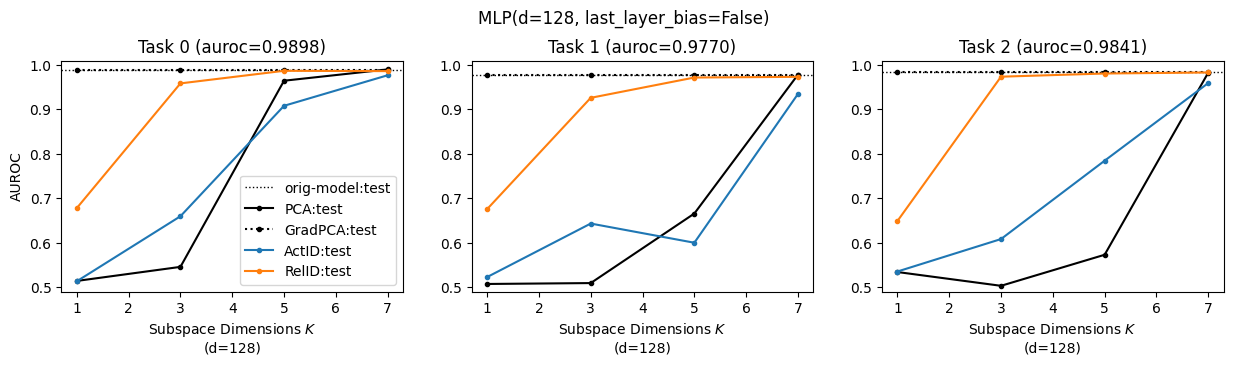

In [94]:
def ls_color(basis_name):
    if basis_name == "PCA":
        return "-", "black"
    elif basis_name == "GradPCA":
        return ":", "black"
    else:
        return "-", None
def viz(arr_basis_classes, max_k=10):
    
    arr_task_ids = np.arange(3)
    plt.figure(figsize=(5*3, 3))
    
    d = model.lin1.weight.shape[0]

    arr_ks = np.linspace(1, max_k, 5).astype(int).tolist() 
    
    plt.suptitle(model, y=1.05)
    
    for task_id in tqdm(arr_task_ids):
        plt.subplot(1, 3, task_id+1)
        plt.title(f"Task {task_id}")
        df = compute_task_auroc_at_k(model, task_id=task_id, arr_ks=arr_ks, arr_basis_names=arr_basis_classes)
        
        for bix, basis_class in tqdm(enumerate(arr_basis_classes), desc=f"task_id={task_id}", disable=True):
            basis_name = basis_class.__name__
            _df = df[
                (df.basis_name == basis_name) 
            ]
            
            if bix == 0:
                
                ref = ref_stats[f"auroc_task_{task_id}_test"]
                plt.title(f"Task {task_id} (auroc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls=":",
                    lw=1,
                    color="k",
                    label="orig-model:test"
                )
            selected = _df.k < max_k
            ls, color = ls_color(basis_name)
            for label in ["test"]:
                plt.plot(
                    _df.k[selected],
                    _df[f"auroc_{label}"][selected],
                    color=color,
                    ls=ls,
                    marker=".",
                    label=f"{basis_name}:{label}"
                )
        plt.ylim([0.5-0.01, 1.01])
        if task_id == 0:
            plt.legend()
            plt.ylabel("AUROC")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
viz(
    arr_basis_classes=[
        PCA,
        GradPCA,
        ActID,
        RelID,
    ]
)

# Decision Boundary

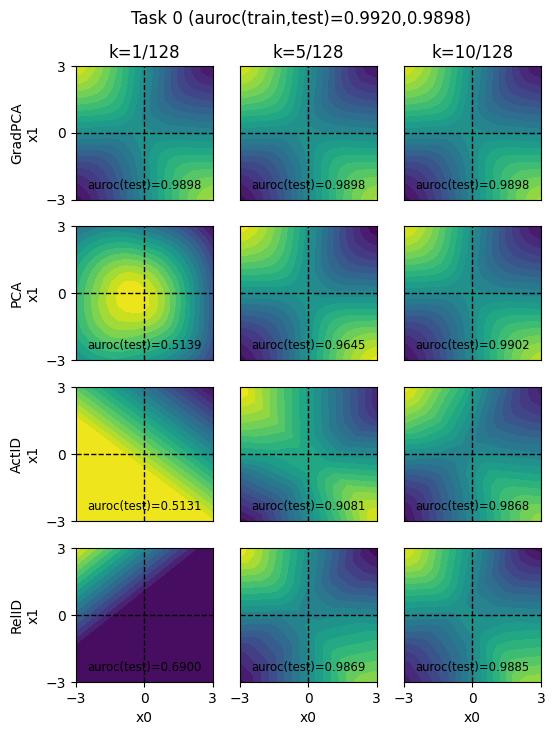

In [102]:
def decision_boundary(task_id, arr_ks=[1, 5, 10]):

    arr_basis_names = [
        GradPCA,
        PCA,
        ActID,
        RelID,
    ]
        
    d = model.lin1.weight.shape[0]
    arr_ks = arr_ks 
    
    nrows = len(arr_basis_names)
    ncols = len(arr_ks)
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    _xx = np.linspace(-3, 3, 20)
    module = getattr(model, "act1")
    plt.figure(figsize=(2*ncols, 2*nrows))
    
    auroc_train = ref_stats[f"auroc_task_{task_id}_train"]
    auroc_test = ref_stats[f"auroc_task_{task_id}_test"]
    plt.suptitle(
        f"Task {task_id} (auroc(train,test)={auroc_train:.4f},{auroc_test:.4f})",
        y=0.95
    )
    
    _, arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    
    for bix, basis_class in enumerate(arr_basis_names):
        basis_name = basis_class.__name__
        
        
        basis: BasisInterface = basis_class(
            arr_logodds=_,
            arr_act=arr_act,
            arr_ctx=arr_ctx
        )


        coord_1, coord_2 = arr_coords[task_id]

        X = np.zeros((400, 3))
        
        xx, yy = np.meshgrid(_xx, _xx)
        
        X[:, coord_1] = xx.reshape(-1)
        X[:, coord_2] = yy.reshape(-1)
        
        X = torch.from_numpy(X).float()
        for kix, k in enumerate(arr_ks):

            mat_proj = basis.get_projection(k=k)

            mat_proj = torch.from_numpy(mat_proj).float()
            
            plt.subplot(nrows, ncols, bix * ncols + kix + 1)
            if bix == 0:
                plt.title(f"k={k}/{d}")
            
            try:
                hook = module.register_forward_hook(construct_fh(mat_proj))
                
                task_logits = model(X)[task_id].detach().numpy()
                
                auroc = estimate_task_auroc(
                    model,
                    dl_test,
                    task_id=task_id
                )
            
            finally:
                hook.remove()
                     
            plt.contourf(
                X[:, coord_1].reshape((20, 20)),
                X[:, coord_2].reshape((20, 20)),
                task_logits.reshape((20, 20)),
                levels=20,
            )
            
            plt.text(
                -2.5, -2.5, 
                f"auroc(test)={auroc:.4f}", 
                fontsize="small",
            )
            
            plt.axhline(0, ls="--", lw=1, color="k")
            plt.axvline(0, ls="--", lw=1, color="k")
            
            if bix == nrows - 1:
                plt.xlabel(f"x{coord_1}")
                plt.xticks([-3, 0, 3])

            else:
                plt.xticks([])
            if kix == 0:
                plt.ylabel(f"{basis_name}\nx{coord_2}")
                plt.yticks([-3, 0, 3])
            else:
                plt.yticks([])

decision_boundary(task_id=0)

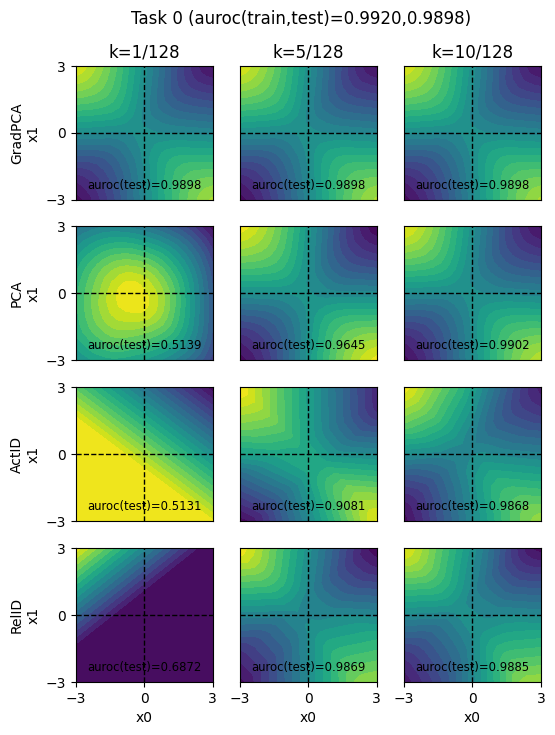

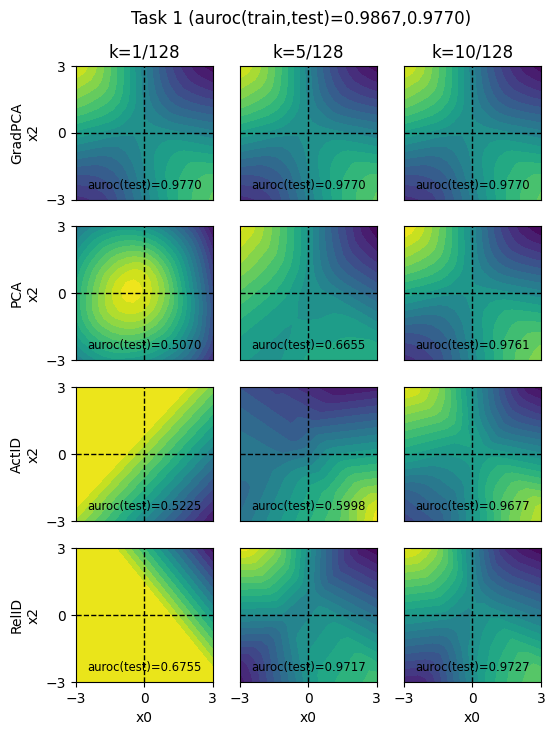

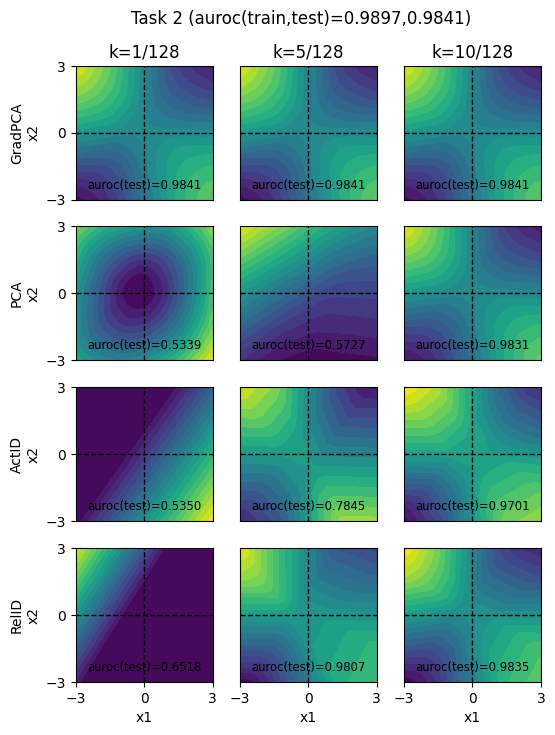

In [103]:
for task_id in range(3):
    decision_boundary(task_id=task_id)
    plt.show()

In [ ]:
print(f"Finished at {datetime.now()}")